In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['Face Mask Dataset']

In [ ]:
# Base directory
base_dir = '/content/dataset/Face Mask Dataset'

# Image properties
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ImageDataGenerators with normalization.
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Creating data generators
train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'Train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'Validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    directory=os.path.join(base_dir, 'Test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)



Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.


In [ ]:
base_dir = '/content/dataset/Face Mask Dataset'

# Listing categories
categories = os.listdir(base_dir)
print("Categories:", categories)

# Listing files from each category
for category in categories:
    category_path = os.path.join(base_dir, category)
    print(f"\nSample files in '{category}':", os.listdir(category_path)[:5])


Categories: ['Validation', 'Test', 'Train']

Sample files in 'Validation': ['WithoutMask', 'WithMask']

Sample files in 'Test': ['WithoutMask', 'WithMask']

Sample files in 'Train': ['WithoutMask', 'WithMask']


In [ ]:
!pip install tensorflow


In [ ]:
# Loading pre-trained MobileNetV2
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

# Adding custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compiling the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#training model on dataset
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 439s 1s/step - accuracy: 0.7193 - loss: 0.5553 - val_accuracy: 0.9563 - val_loss: 0.2005
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.9464 - loss: 0.1931 - val_accuracy: 0.9750 - val_loss: 0.1235
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 427s 1s/step - accuracy: 0.9662 - loss: 0.1300 - val_accuracy: 0.9787 - val_loss: 0.0929
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 425s 1s/step - accuracy: 0.9718 - loss: 0.1044 - val_accuracy: 0.9812 - val_loss: 0.0766
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 416s 1s/step - accuracy: 0.9772 - loss: 0.0813 - val_accuracy: 0.9825 - val_loss: 0.0660


In [ ]:
# Evaluating the model on the test set


test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")



31/31 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9903 - loss: 0.0609
Test Accuracy: 0.9869


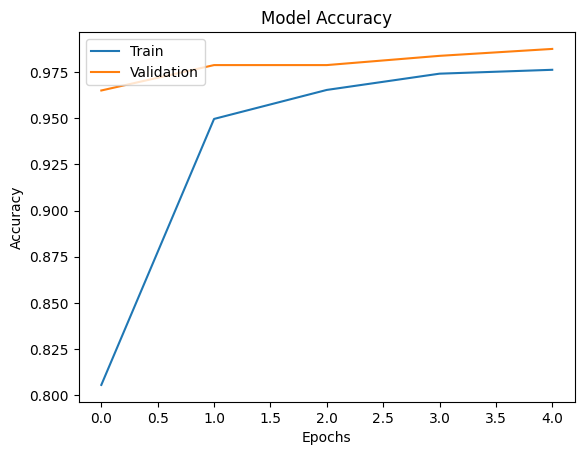

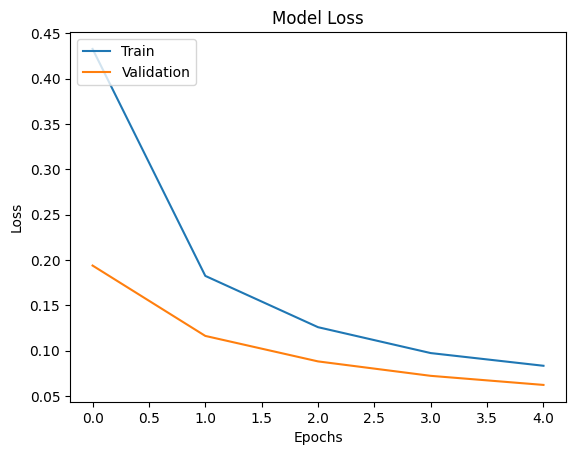

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
# Save the trained model to a file
model.save('face_mask_detection_model.h5')



In [ ]:
# Get true labels from the generator
true_labels = test_generator.classes

# Predict probabilities
pred_probs = model.predict(test_generator)
pred_labels = (pred_probs > 0.5).astype("int32").flatten()


31/31 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step


32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step
Classification Report:

              precision    recall  f1-score   support

    WithMask       0.98      0.99      0.99       483
 WithoutMask       0.99      0.98      0.99       509

    accuracy                           0.99       992
   macro avg       0.99      0.99      0.99       992
weighted avg       0.99      0.99      0.99       992



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


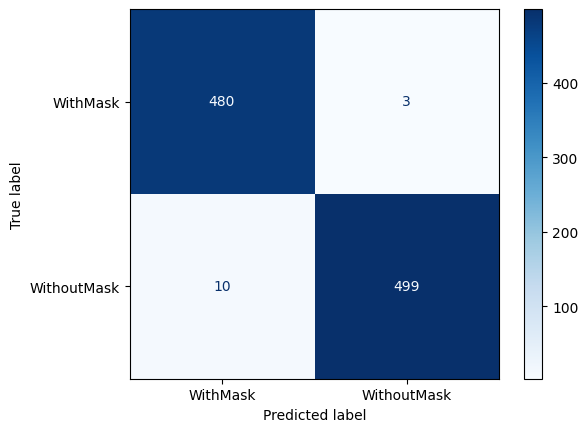

In [ ]:
# Resetting generator
test_generator.reset()

# Predict
pred_probs = model.predict(test_generator, steps=test_generator.samples // test_generator.batch_size + 1, verbose=1)
pred_labels = (pred_probs > 0.5).astype("int32").flatten()

# Get true labels
true_labels = test_generator.classes

# Trim predictions to length of true_labels if needed
if len(pred_labels) != len(true_labels):
    pred_labels = pred_labels[:len(true_labels)]

# Generating report
print("Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=['WithMask', 'WithoutMask']))

#  confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['WithMask', 'WithoutMask'])
disp.plot(cmap='Blues')


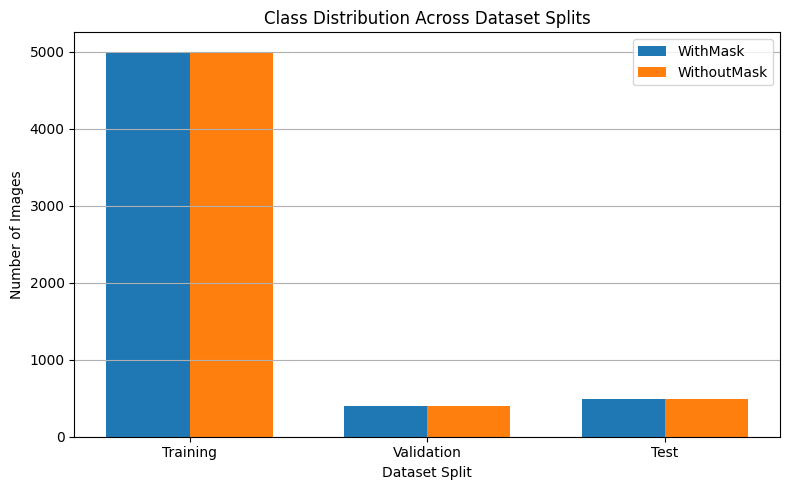

In [ ]:
splits = ['Training', 'Validation', 'Test']
with_mask = [5000, 400, 496]
without_mask = [5000, 400, 496]

x = np.arange(len(splits))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, with_mask, width, label='WithMask')
plt.bar(x + width/2, without_mask, width, label='WithoutMask')

plt.xlabel('Dataset Split')
plt.ylabel('Number of Images')
plt.title('Class Distribution Across Dataset Splits')
plt.xticks(x, splits)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
